In [3]:

import os, gc, pandas as pd, numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


DATA_ROOT = '/content/drive/MyDrive/MLOmics_βVAE_Focused'
assert os.path.isdir(DATA_ROOT), f'Folder not found: {DATA_ROOT}'

CANCERS = {
    'Classification_datasets': ['GS-BRCA','GS-COAD','GS-GBM','GS-LGG','GS-OV'],
    'Clustering_datasets'    : ['ACC','KIRC','LIHC','LUAD','LUSC','PRAD','THCA']
}


def top_rows(df, k):                       # top-variance filter
    return df.loc[df.var(axis=1).nlargest(k).index]

def load_cancer(cancer, branch):
    top_dir = f'{DATA_ROOT}/{branch}/{cancer}/Top'
    if not os.path.isdir(top_dir):
        print('  ⚠', cancer, 'Top folder missing'); return None

    frames = []
    for omic in ['mRNA','miRNA','CNV','Methy']:
        csv = f"{top_dir}/{cancer.replace('GS-','')}_{omic}_top.csv"
        if not os.path.isfile(csv): continue
        df  = pd.read_csv(csv, index_col=0)
        k   = 200 if omic == 'miRNA' else 1_000
        df  = top_rows(df, k).T                              # patients × features
        df.columns = [f'{cancer}_{omic}_{i}' for i in range(df.shape[1])]
        frames.append(df)

    if not frames:
        print('  ⚠', cancer, 'no omics'); return None

    merged = pd.concat(frames, axis=1, ignore_index=True)
    merged.columns = [f'{cancer}_feat_{i}' for i in range(merged.shape[1])]
    merged.index   = [f'{cancer}_{i:05d}' for i in range(len(merged))]
    print('  ✔', cancer, merged.shape)
    return merged.astype('float32')

frames = []
for branch, lst in CANCERS.items():
    for cancer in lst:
        df = load_cancer(cancer, branch)
        if df is not None:
            frames.append(df)

assert frames, 'No data loaded – check DATA_ROOT'


raw = pd.concat(frames, axis=0, copy=False)
imp    = SimpleImputer(strategy='mean')
scaler = StandardScaler()

tmp = pd.DataFrame(imp.fit_transform(raw),
                   index=raw.index,
                   columns=raw.columns).astype('float32')

combined_data = pd.DataFrame(scaler.fit_transform(tmp).astype('float32'),
                             index=tmp.index,
                             columns=tmp.columns)

print('\n🎉  combined_data:', combined_data.shape,
      '| RAM ≈', f'{combined_data.memory_usage().sum()/1024**3:.2f} GB')


Mounted at /content/drive
  ✔ GS-BRCA (671, 3200)
  ✔ GS-COAD (260, 3200)
  ✔ GS-GBM (244, 3200)
  ✔ GS-LGG (247, 3200)
  ✔ GS-OV (284, 3200)
  ✔ ACC (177, 3200)
  ✔ KIRC (314, 3200)
  ✔ LIHC (364, 3200)
  ✔ LUAD (450, 3200)
  ✔ LUSC (363, 3200)
  ✔ PRAD (368, 3200)
  ✔ THCA (291, 3200)

🎉  combined_data: (4033, 38400) | RAM ≈ 0.58 GB


In [4]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# dataframe → numpy → torch tensor
X_tensor = torch.from_numpy(combined_data.values).float()

batch_size = 64
dataset     = TensorDataset(X_tensor)          \
dataloader  = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print('Tensor shape :', X_tensor.shape)        # (4033, 38400)
print('Batches      :', len(dataloader))


Tensor shape : torch.Size([4033, 38400])
Batches      : 64


In [5]:
import torch.nn as nn
import torch.nn.functional as F

class BetaVAE(nn.Module):
    def __init__(self, input_dim, latent_dim=32, beta=4.0):
        super().__init__()
        self.beta = beta

        # encoder
        self.enc = nn.Sequential(
            nn.Linear(input_dim, 2048), nn.ReLU(),
            nn.Linear(2048, 512),       nn.ReLU()
        )
        self.mu     = nn.Linear(512, latent_dim)
        self.logvar = nn.Linear(512, latent_dim)

        # decoder
        self.dec = nn.Sequential(
            nn.Linear(latent_dim, 512),  nn.ReLU(),
            nn.Linear(512, 2048),        nn.ReLU(),
            nn.Linear(2048, input_dim)
        )

    def encode(self, x):
        h = self.enc(x)
        return self.mu(h), self.logvar(h)

    def reparam(self, mu, logvar):
        std = (0.5 * logvar).exp()
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encode(x)
        z          = self.reparam(mu, logvar)
        recon      = self.dec(z)
        return recon, mu, logvar, z

def beta_vae_loss(recon, x, mu, logvar, beta):
    rec_loss = F.mse_loss(recon, x, reduction='sum')
    kl_loss  = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return rec_loss + beta * kl_loss, rec_loss, kl_loss


In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = BetaVAE(input_dim=combined_data.shape[1], latent_dim=32, beta=4.0).to(device)

optimizer   = torch.optim.Adam(model.parameters(), lr=1e-4)
epochs      = 100

for epoch in range(1, epochs + 1):
    model.train()
    tot, rec, kl = 0, 0, 0
    for (x,) in dataloader:
        x = x.to(device)
        optimizer.zero_grad()
        recon, mu, logvar, _ = model(x)
        loss, r, k = beta_vae_loss(recon, x, mu, logvar, model.beta)
        loss.backward()
        optimizer.step()
        tot += loss.item(); rec += r.item(); kl += k.item()

    if epoch % 10 == 0:
        n = len(dataloader.dataset)
        print(f'Epoch {epoch:3d}  |  loss {tot/n:.4f}  rec {rec/n:.4f}  kl {kl/n:.4f}')


Epoch  10  |  loss 29404.2214  rec 28790.7969  kl 153.3561
Epoch  20  |  loss 26618.0071  rec 25918.9043  kl 174.7757
Epoch  30  |  loss 24408.6620  rec 23626.6190  kl 195.5108
Epoch  40  |  loss 22625.2313  rec 21792.3261  kl 208.2263
Epoch  50  |  loss 21130.6661  rec 20260.4178  kl 217.5620
Epoch  60  |  loss 19914.0274  rec 19019.9894  kl 223.5095
Epoch  70  |  loss 18797.9837  rec 17882.1053  kl 228.9696
Epoch  80  |  loss 17908.8369  rec 16980.7023  kl 232.0336
Epoch  90  |  loss 17013.3050  rec 16078.4105  kl 233.7236
Epoch 100  |  loss 16250.7683  rec 15311.3259  kl 234.8606


In [ ]:

model.eval()#YE CHEEJ SE HAM LATENT REPRESENTATION NIKAAL RAHE HAIN
with torch.no_grad():
    Z = []
    for (x,) in dataloader:
        mu, _ = model.encode(x.to(device))
        Z.append(mu.cpu())
    Z = torch.cat(Z).numpy()  # Shape: (4033, 32)

print(f"Extracted latent representations: {Z.shape}")

# Discover molecular subtypes using K-means
from sklearn.cluster import KMeans
import numpy as np

n_subtypes = 5  # Start with 5 cross-cancer subtypes
kmeans = KMeans(n_clusters=n_subtypes, random_state=42)
subtype_labels = kmeans.fit_predict(Z)

print(f"Discovered {n_subtypes} cross-cancer molecular subtypes:")
for i in range(n_subtypes):
    count = np.sum(subtype_labels == i)
    print(f"   Subtype {i+1}: {count} patients ({count/len(subtype_labels)*100:.1f}%)")


Extracted latent representations: (4033, 32)
Discovered 5 cross-cancer molecular subtypes:
   Subtype 1: 455 patients (11.3%)
   Subtype 2: 670 patients (16.6%)
   Subtype 3: 347 patients (8.6%)
   Subtype 4: 2205 patients (54.7%)
   Subtype 5: 356 patients (8.8%)


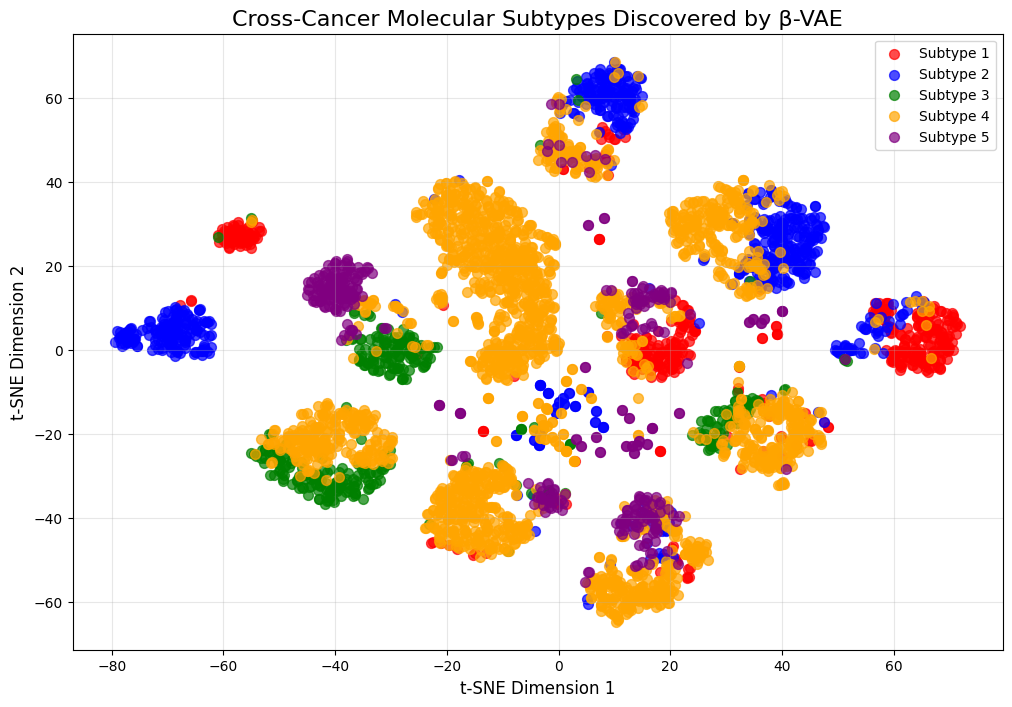

🎯 If you see distinct clusters, your β-VAE successfully discovered cross-cancer subtypes!


In [ ]:

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Reduce to 2D for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
Z_2d = tsne.fit_transform(Z)

# Plot discovered subtypes
plt.figure(figsize=(12, 8))
colors = ['red', 'blue', 'green', 'orange', 'purple']

for i in range(n_subtypes):
    mask = subtype_labels == i
    plt.scatter(Z_2d[mask, 0], Z_2d[mask, 1],
               c=colors[i], label=f'Subtype {i+1}',
               alpha=0.7, s=50)

plt.title('Cross-Cancer Molecular Subtypes Discovered by β-VAE', fontsize=16)
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("🎯 If you see distinct clusters, your β-VAE successfully discovered cross-cancer subtypes!")



📊 Cross-Cancer Subtype Distribution:
Subtype    0    1    2     3    4   All
Cancer                                 
ACC       24   26   12    99   16   177
GS-BRCA   75   99   78   360   59   671
GS-COAD   38   40   16   143   23   260
GS-GBM    33   41   23   129   18   244
GS-LGG    18   44   25   137   23   247
GS-OV     32   37   24   165   26   284
KIRC      32   60   24   174   24   314
LIHC      45   71   26   198   24   364
LUAD      48   74   40   243   45   450
LUSC      32   63   25   202   41   363
PRAD      43   64   27   202   32   368
THCA      35   51   27   153   25   291
All      455  670  347  2205  356  4033


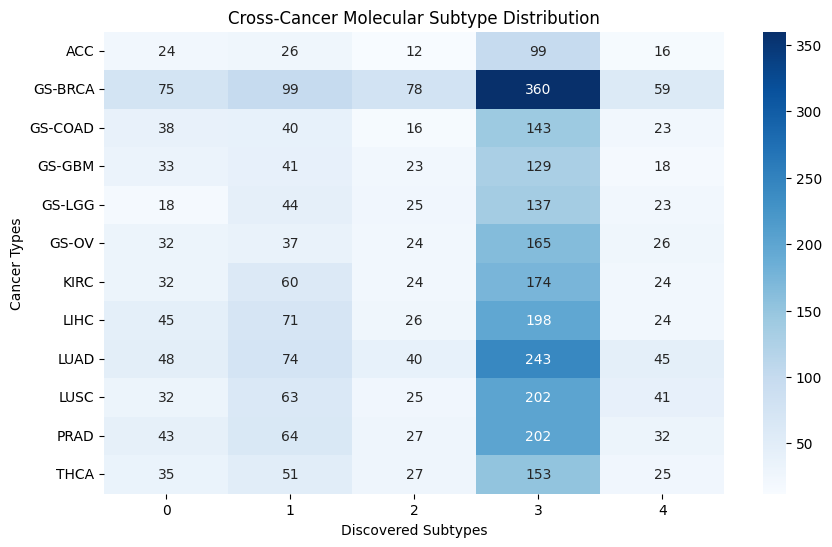

In [9]:
#Map subtypes back to cancer types
patient_ids = combined_data.index
cancer_types = [pid.split('_')[0] for pid in patient_ids]

# ye basically creates cross-tabulation
import pandas as pd
subtype_cancer_df = pd.DataFrame({
    'Patient': patient_ids,
    'Cancer': cancer_types,
    'Subtype': subtype_labels
})


cross_tab = pd.crosstab(subtype_cancer_df['Cancer'],
                        subtype_cancer_df['Subtype'],
                        margins=True)
print("\n📊 Cross-Cancer Subtype Distribution:")
print(cross_tab)

# Heatmap visualization
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.heatmap(cross_tab.iloc[:-1, :-1], annot=True, fmt='d', cmap='Blues')
plt.title('Cross-Cancer Molecular Subtype Distribution')
plt.ylabel('Cancer Types')
plt.xlabel('Discovered Subtypes')
plt.show()
